#Case Study 2
###Group: Sean Feeny and Shota Muraishi
Model the time series data using some form of ensemble models with trees such as XGboost:

- Split your data into training and testing or use k-fold cross validation. Discuss how much of your data you will use for training and the trade off you will face with this choice.

- Make derived variables using the date variable. Discuss how many derived variables you will make be care to try to minimize the use of colinear variables.

- Discuss the intricacies of modeling with the ensemble forest method you chose.

- Include at least one lag term in the data. Optional: include several lags and use a PACF to decide how many lags to include.

- Discuss variable selection and variable importance.

- Forecast on the test/cross validation data and predict into the future.

- Model the data using one of these alternative methods and compare your results: prophet model, ARIMA model, an ensemble with linear regression and/or KNN.

- Discuss the importance of the data and why time series forecasting is important.

###Uploading and adjusting the format of the data:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
color_pal = sns.color_palette
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX



In [ ]:
from google.colab import files

uploaded = files.upload()


Saving Truck_sales.csv to Truck_sales (2).csv


In [ ]:
for fn in uploaded.keys():
  # Assuming the uploaded file is a CSV, read it into a pandas DataFrame
  df = pd.read_csv(fn)


display(df.head())

,Month-Year,Number_Trucks_Sold
0,03-Jan,155
1,03-Feb,173
2,03-Mar,204
3,03-Apr,219
4,03-May,223


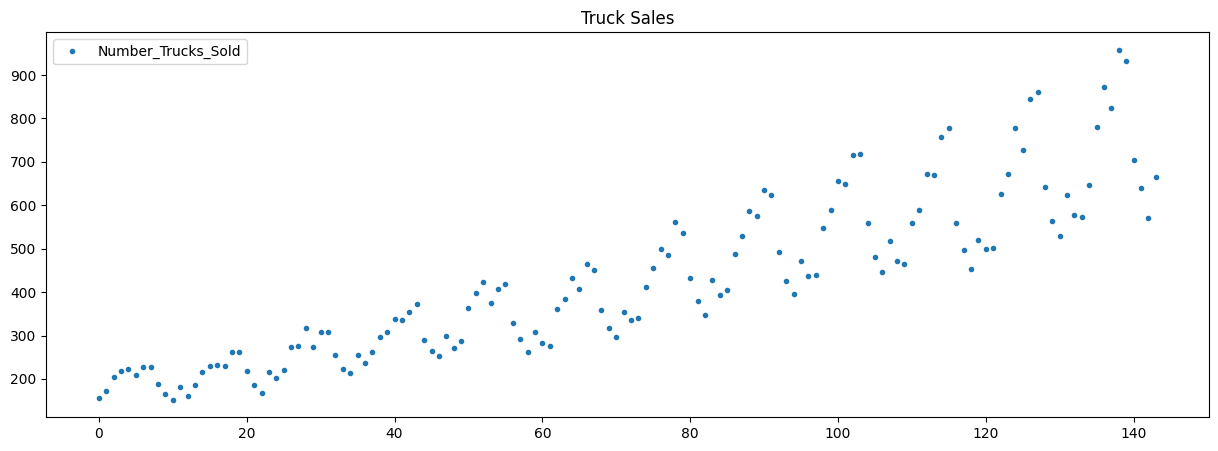

In [ ]:
#plotting the truck sales data:
df.plot(style='.',
        figsize=(15, 5),
        color=color_pal()[0],
        title='Truck Sales')
plt.show()

In [ ]:
# Set the Month-Year column as the index and convert to datetime
df['Month-Year'] = pd.to_datetime(df['Month-Year'], format='%y-%b')
df = df.set_index('Month-Year')
df.index.name = None
display(df.head())


,Number_Trucks_Sold
2003-01-01,155
2003-02-01,173
2003-03-01,204
2003-04-01,219
2003-05-01,223


- Split your data into training and testing or use k-fold cross validation. Discuss how much of your data you will use for training and the trade off you will face with this choice.

After testing some different fold numbers, we decided to split our data with 5-fold cross validation because it had the lowest error (we will be using RMSE) out of the fold numbers we tried. We used one year for each fold because the data has yearly seasonality. The tradeoff here is that we gain the stability granted by cross-validation but lose quite a bit of data for some of the smaller folds because time series folds mean you lose data after the fold. This is especially true for the first and second folds, for which we lose 4 and 3 years of data, respectively.

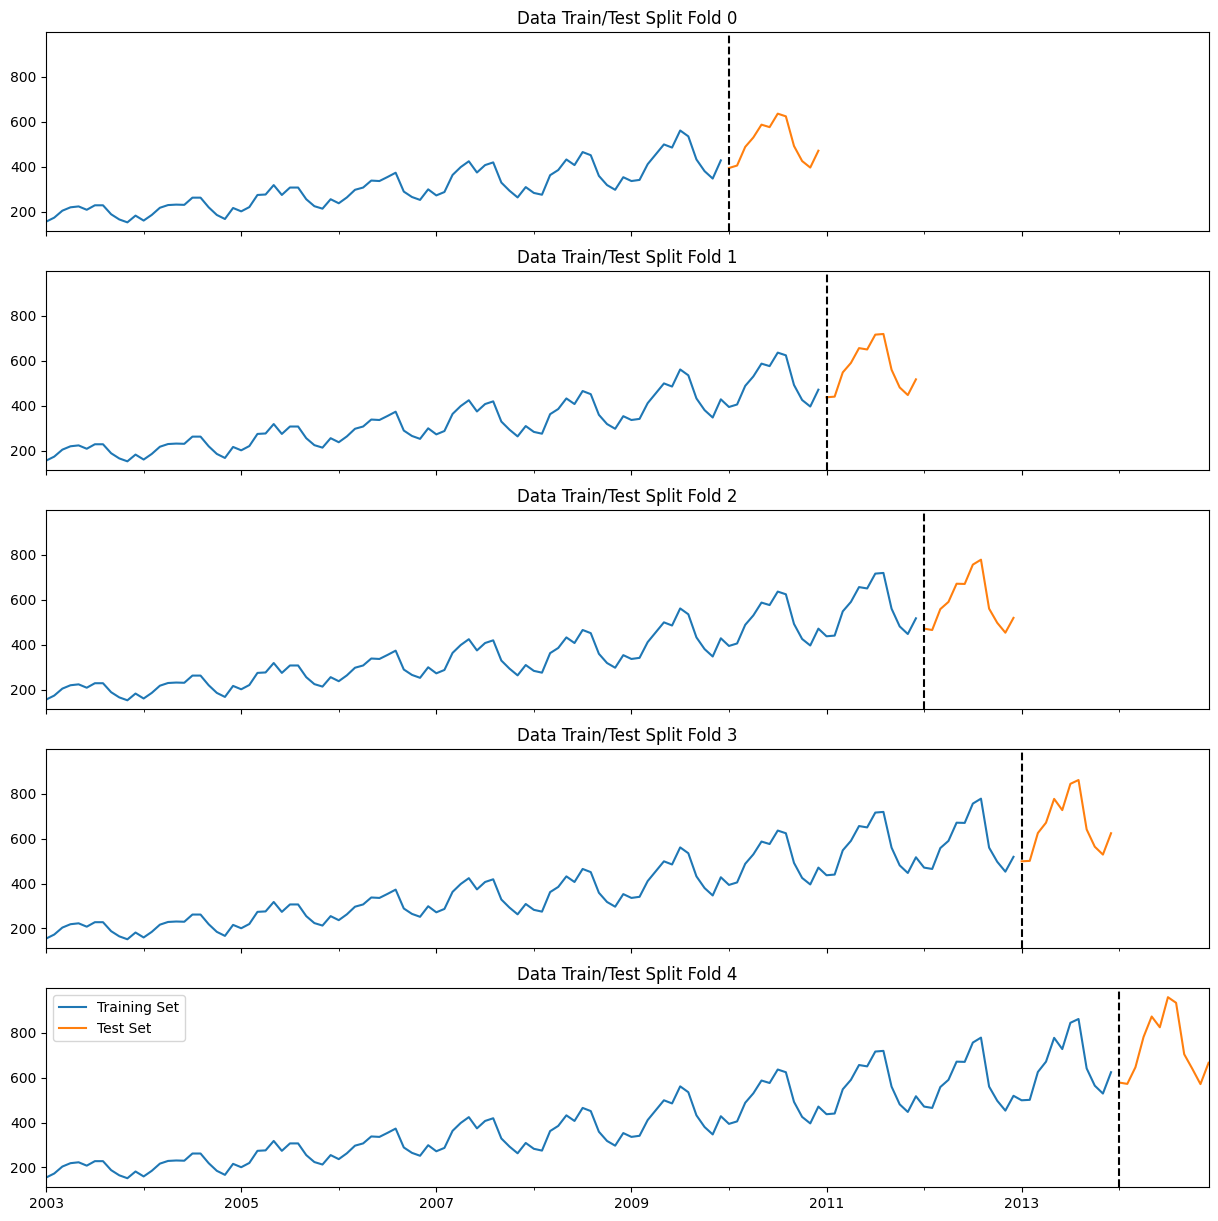

In [ ]:
#splitting the data for 5-fold cross validation
folds = 5
tss = TimeSeriesSplit(n_splits=folds, test_size=12, gap=0)
df = df.sort_index()
fig, axs = plt.subplots(folds, 1, figsize=(15, 15), sharex=True, sharey=True)
fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['Number_Trucks_Sold'].plot(ax=axs[fold],
                          label='Training Set',
                          title=f'Data Train/Test Split Fold {fold}')
    test['Number_Trucks_Sold'].plot(ax=axs[fold],
                         label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
plt.legend()

plt.show()

- Make derived variables using the date variable. Discuss how many derived
variables you will make be care to try to minimize the use of colinear variables.


Since our date variable only includes month and year, the most obvious derived variables based on date are month, quarter, and year. We created all three of these to try their effects, though month and quarter are colinear so we will not use both in our final model

In [ ]:
#creating derived variables based on the date variable
def create_features(df):
    df = df.copy()
    df['year'] = df.index.year
    df['quarter'] = df.index.quarter  #quarter and month are colinear, but we tried adding both to see which worked better
    df['month'] = df.index.month
    return df

df = create_features(df)
display(df.head())


,Number_Trucks_Sold,year,quarter,month
2003-01-01,155,2003,1,1
2003-02-01,173,2003,1,2
2003-03-01,204,2003,1,3
2003-04-01,219,2003,2,4
2003-05-01,223,2003,2,5


- Discuss the intricacies of modeling with the ensemble forest method you chose.

We did tests of a random forest model and XGBoost, but XGBoost had a better result with a slightly lower error score when using 5-fold cross validation, so we settled on XGBoost.

XGBoost uses trees to create many weak learners, which are combined to make a strong learner by training on the errors of the previous weak learners.

- Include at least one lag term in the data. Optional: include several lags and use a PACF to decide how many lags to include.

We created a PACF plot and an ACF plot to determine which lags were significant. The most significant lags on the PACF plot are 1, 7, and 13, while the most significant on the ACF plot is 12 due to the yearly seasonality of the data. However, our prediction interval we chose is 12 months, so lags smaller than 12 would cause data leakage by including some values from the test set for each fold. Instead, we decided to add lags of 12, 13, 19 (because this is 7+12), and 24 to see which ones are most predictive and narrow down from there. We also tried lags 12-24 with sequential feature selection, but none of the others were particularly important, so we did not keep the other lags

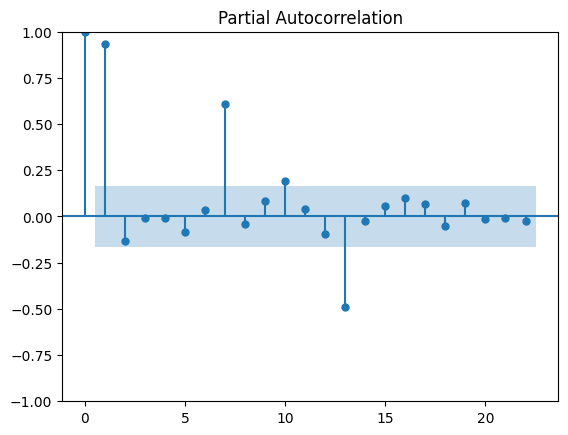

In [ ]:
# Plot PACF for 'Number_Trucks_Sold'
plot_pacf(df['Number_Trucks_Sold'], alpha=0.05)
plt.show()

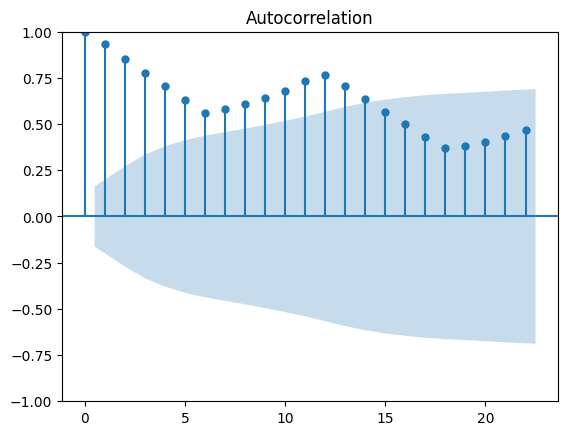

In [ ]:
# Plot ACF for 'Number_Trucks_Sold'
plot_acf(df['Number_Trucks_Sold'], alpha=0.05)
plt.show()

In [ ]:
#adding lags to the dataset
def add_lags(df):
    target_map = df['Number_Trucks_Sold'].to_dict()
    df['lag12'] = (df.index - pd.DateOffset(months=12)).map(target_map)
    df['lag13'] = (df.index - pd.DateOffset(months=13)).map(target_map)
    df['lag19'] = (df.index - pd.DateOffset(months=19)).map(target_map)
    df['lag24'] = (df.index - pd.DateOffset(months=24)).map(target_map)
    return df
df = add_lags(df)



- Discuss variable selection and variable importance.

Using the code cell below, we used sequential forward selection on the variables we have made so far to get an initial idea of the most important features and it selected lag 12, lag 13, and lag 24, excluding year and month. We found with separate experimentation that adding year and lag 19 improved the CV score somewhat, but month and quarter made it worse. The lowest CV score we got was 45.6, which used year, lag 12, lag 13, lag 19, and lag 24. We found max tree depth of 7 to have the lowest CV scores, but because this is on cross validation data, we did not think this was overfitting

In [ ]:
#Using sequential feature selection:
X = df.drop(columns=['Number_Trucks_Sold'])
y = df['Number_Trucks_Sold']
# Model
model = xgb.XGBRegressor(base_score=1, booster='gbtree',
                           n_estimators=2000,
                           objective='reg:squarederror',
                           max_depth=7,
                           learning_rate=0.01)

# Time series CV
tscv = TimeSeriesSplit(n_splits=5)

# Forward SFS
sfs = SequentialFeatureSelector(
    model,
    n_features_to_select= "auto",
    direction='forward',
    cv=tscv,
    n_jobs=-1
)

sfs.fit(X, y)

# Selected features
selected_features = X.columns[sfs.get_support()]
print(selected_features)

Index(['lag12', 'lag13', 'lag24'], dtype='object')


In [ ]:
tss = TimeSeriesSplit(n_splits=5, test_size=12, gap=0)
df = df.sort_index()
fold = 0
preds = []
scores = []

for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    train = create_features(train)
    test = create_features(test)

    FEATURES = [ 'year', 'lag19',
                 'lag12','lag13', 'lag24']
    TARGET = 'Number_Trucks_Sold'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    reg = xgb.XGBRegressor(base_score = 1, booster='gbtree',
                           n_estimators=2000,
                           early_stopping_rounds=50,
                           objective='reg:squarederror',
                           max_depth=7,
                           learning_rate=0.01)
    reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=200)
    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

[0]	validation_0-rmse:312.21745	validation_1-rmse:504.44581
[200]	validation_0-rmse:50.94007	validation_1-rmse:142.67791
[400]	validation_0-rmse:15.15286	validation_1-rmse:64.94406
[600]	validation_0-rmse:10.93191	validation_1-rmse:44.73866
[800]	validation_0-rmse:10.36077	validation_1-rmse:37.80341
[1000]	validation_0-rmse:10.27141	validation_1-rmse:35.39262
[1200]	validation_0-rmse:10.25326	validation_1-rmse:34.57579
[1400]	validation_0-rmse:10.24884	validation_1-rmse:34.21688
[1600]	validation_0-rmse:10.24759	validation_1-rmse:34.14890
[1800]	validation_0-rmse:10.24725	validation_1-rmse:34.13484
[1999]	validation_0-rmse:10.24713	validation_1-rmse:34.13015
[0]	validation_0-rmse:341.98292	validation_1-rmse:566.90775
[200]	validation_0-rmse:55.09307	validation_1-rmse:143.65053
[400]	validation_0-rmse:14.75815	validation_1-rmse:63.81484
[600]	validation_0-rmse:10.09919	validation_1-rmse:46.10081
[800]	validation_0-rmse:9.66564	validation_1-rmse:40.67930
[1000]	validation_0-rmse:9.60611	

- Forecast on the test/cross validation data and predict into the future.

Using the predictions saved in preds in the code cell above, we get the predictions graphed below for each fold:

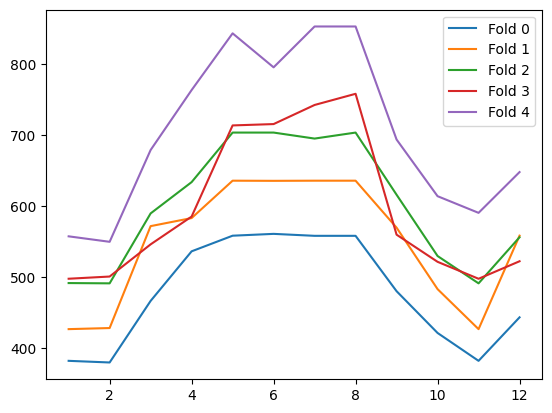

In [ ]:
#plot the predictions for each fold
predsdf = []
m = list(range(1, 13))
for i in range(len(preds)):
    plt.plot(m, preds[i], label='Fold '+ str(i))
    predsdf.append(pd.Series(preds[i], index=df.iloc[val_idx].index+pd.DateOffset(months=12*(i-4))))
plt.legend()
plt.show()


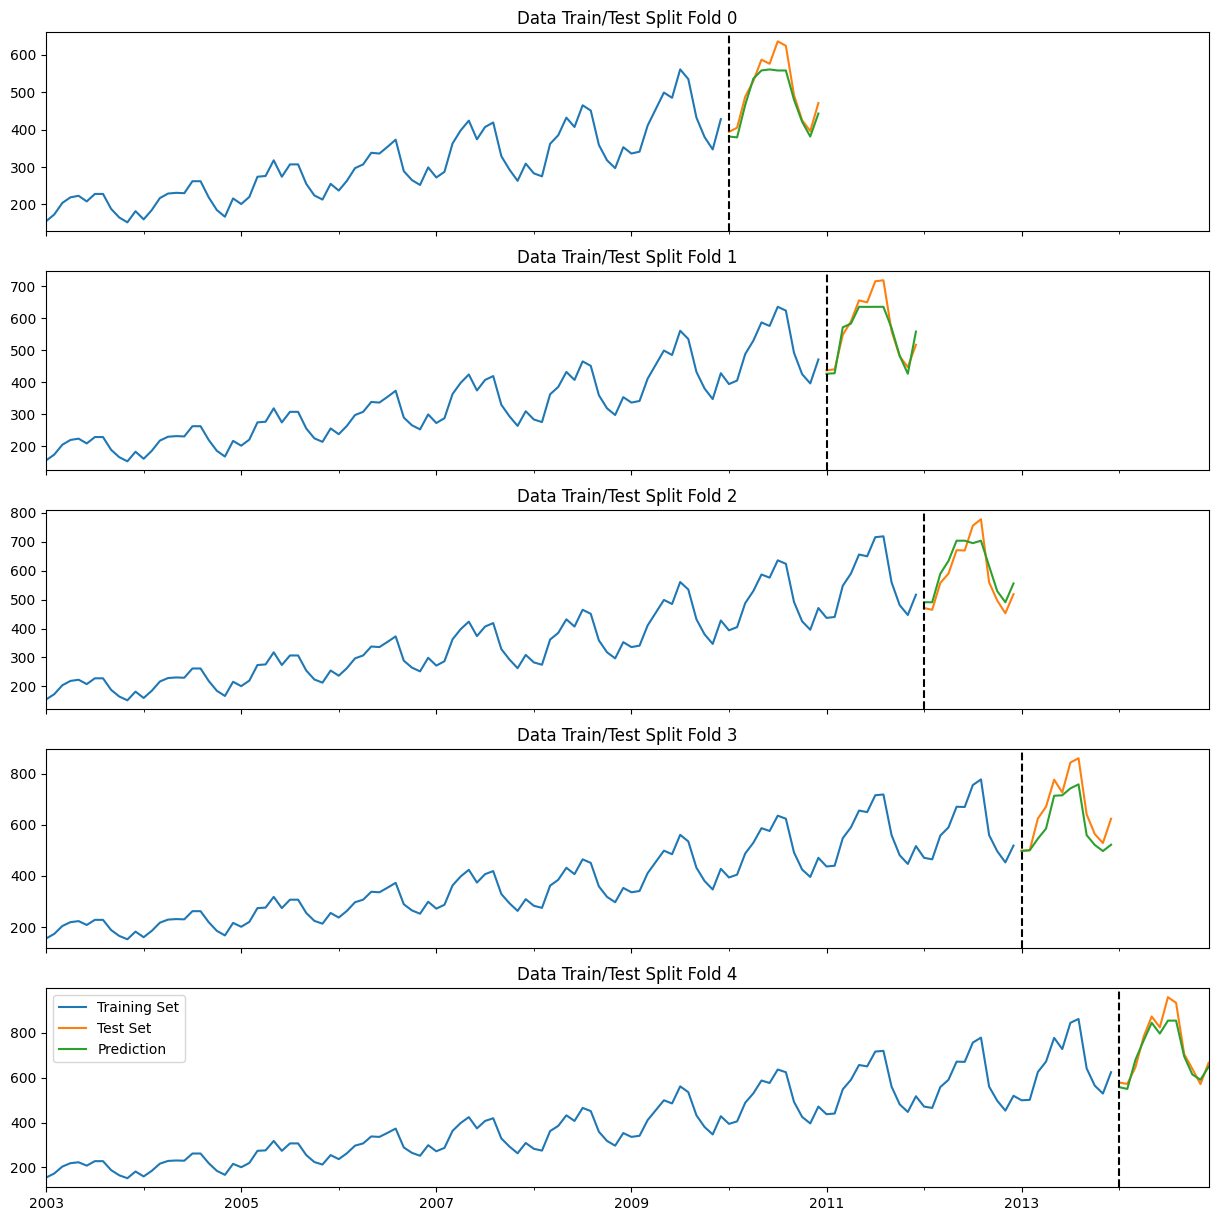

In [ ]:
#splitting the data for 5-fold cross validation
folds = 5
tss = TimeSeriesSplit(n_splits=folds, test_size=12,gap=0)
df = df.sort_index()
fig, axs = plt.subplots(folds, 1, figsize=(15, 15), sharex=True)
fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['Number_Trucks_Sold'].plot(ax=axs[fold],
                          label='Training Set',
                          title=f'Data Train/Test Split Fold {fold}')
    test['Number_Trucks_Sold'].plot(ax=axs[fold],
                         label='Test Set')
    predsdf[fold].plot(ax=axs[fold],
                         label='Prediction')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
plt.legend()

plt.show()

[0]	validation_0-rmse:462.76129
[200]	validation_0-rmse:72.22296
[400]	validation_0-rmse:16.53030
[600]	validation_0-rmse:8.94536
[800]	validation_0-rmse:8.03569
[1000]	validation_0-rmse:7.89557
[1200]	validation_0-rmse:7.85389
[1400]	validation_0-rmse:7.83929
[1600]	validation_0-rmse:7.83269
[1800]	validation_0-rmse:7.82931
[1999]	validation_0-rmse:7.82758


,Number_Trucks_Sold,year,quarter,month,lag12,lag13,lag19,lag24,isFuture
2015-08-01,NaN,2015,3,8,933.0,958.0,578.0,861.0,True
2015-09-01,NaN,2015,3,9,704.0,933.0,572.0,641.0,True
2015-10-01,NaN,2015,4,10,639.0,704.0,646.0,564.0,True
2015-11-01,NaN,2015,4,11,571.0,639.0,781.0,529.0,True
2015-12-01,NaN,2015,4,12,666.0,571.0,872.0,624.0,True


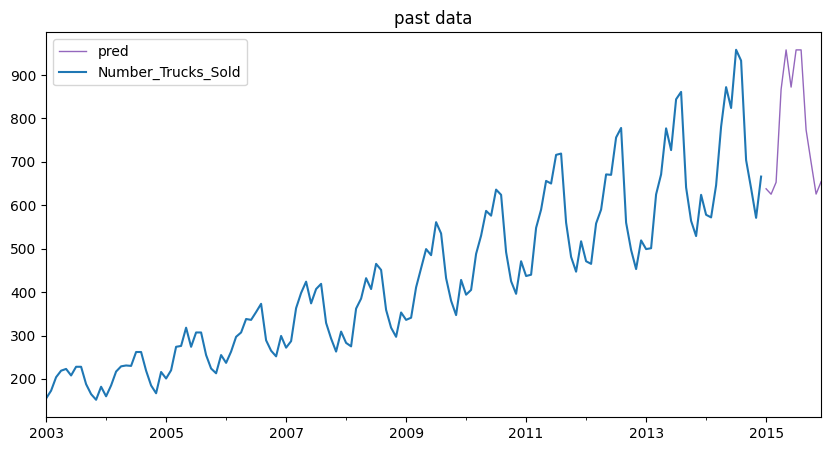

In [ ]:
#create a prediction for the future
df = create_features(df)
FEATURES = [ 'year', 'lag19',
                 'lag12','lag13', 'lag24']
TARGET = 'Number_Trucks_Sold'

X_all = df[FEATURES]
y_all = df[TARGET]

reg = xgb.XGBRegressor(base_score=1,
                       booster='gbtree',
                       n_estimators=2000,
                       objective='reg:squarederror',
                       max_depth=7,
                       learning_rate=0.01)
reg.fit(X_all, y_all,
        eval_set=[(X_all, y_all)],
        verbose=200)
df.index.max()
# Create future dataframe with monthly frequency
future = pd.date_range(start=df.index.max() + pd.DateOffset(months=1),
                       end=df.index.max() + pd.DateOffset(years=1), freq='MS')
future_df = pd.DataFrame(index=future)
future_df['isFuture'] = True
df['isFuture'] = False
df_and_future = pd.concat([df, future_df])

# Re-apply create_features and add_lags on the combined dataframe
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future) # This will now use the corrected add_lags
display(df_and_future.tail()) # Display tail to check the new future rows
future_w_features = df_and_future.query('isFuture').copy()
future_w_features['pred'] = reg.predict(future_w_features[FEATURES])
future_w_features['pred'].plot(figsize=(10, 5),
                               color=color_pal()[4],
                               ms=1,
                               lw=1,
                               title='Future Prediction')
df['Number_Trucks_Sold'].plot(title='past data')

plt.legend()
plt.show()


Our predictions on the CV folds are generally reasonable in shape, but they fail to fully capture the peaks of the data and tend to be a bit too low. The same is likely true for the future prediction, though it seems fairly reasonable

- Model the data using one of these alternative methods and compare your results: prophet model, ARIMA model, an ensemble with linear regression and/or KNN.

We used the Seasonal ARIMA model with cross-validation on the existing data and also to predict the future

In [ ]:
tss = TimeSeriesSplit(n_splits=5, test_size=12, gap=0)
df = df.sort_index()
fold = 0
preds = []
scores = []

for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    train = create_features(train)
    test = create_features(test)
    #FEATURES = [ 'year', 'lag19',
    #             'lag12','lag13', 'lag24']
    TARGET = 'Number_Trucks_Sold'

    #X_train = train[FEATURES]

    y_train = train[TARGET]

    #X_test = test[FEATURES]
    y_test = test[TARGET]
    model = SARIMAX(y_train, order=(2,1,2), seasonal_order=(2,1,2,12))
    model_fit = model.fit(disp=False)
    forecast = model_fit.forecast(steps=len(test))
    y_pred = forecast
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)


print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: Va

Score across folds 30.9654
Fold scores:[np.float64(22.93087438046169), np.float64(17.326628849574114), np.float64(42.644862563581796), np.float64(46.77980351296797), np.float64(25.144685111773544)]


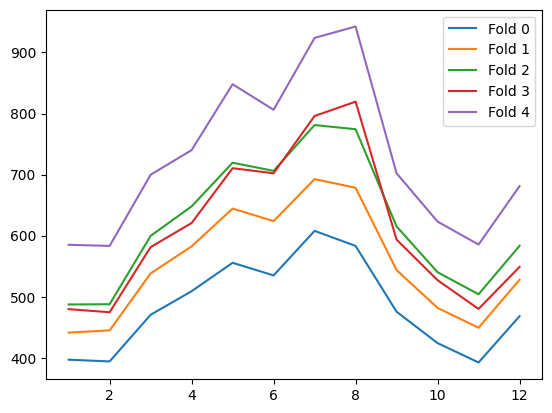

In [ ]:
#plot the predictions for each fold
predsdf = []
m = list(range(1, 13))
for i in range(len(preds)):
    plt.plot(m, preds[i], label='Fold '+ str(i))
    predsdf.append(pd.Series(preds[i], index=df.iloc[val_idx].index+pd.DateOffset(months=12*(i-4))))
plt.legend()
plt.show()

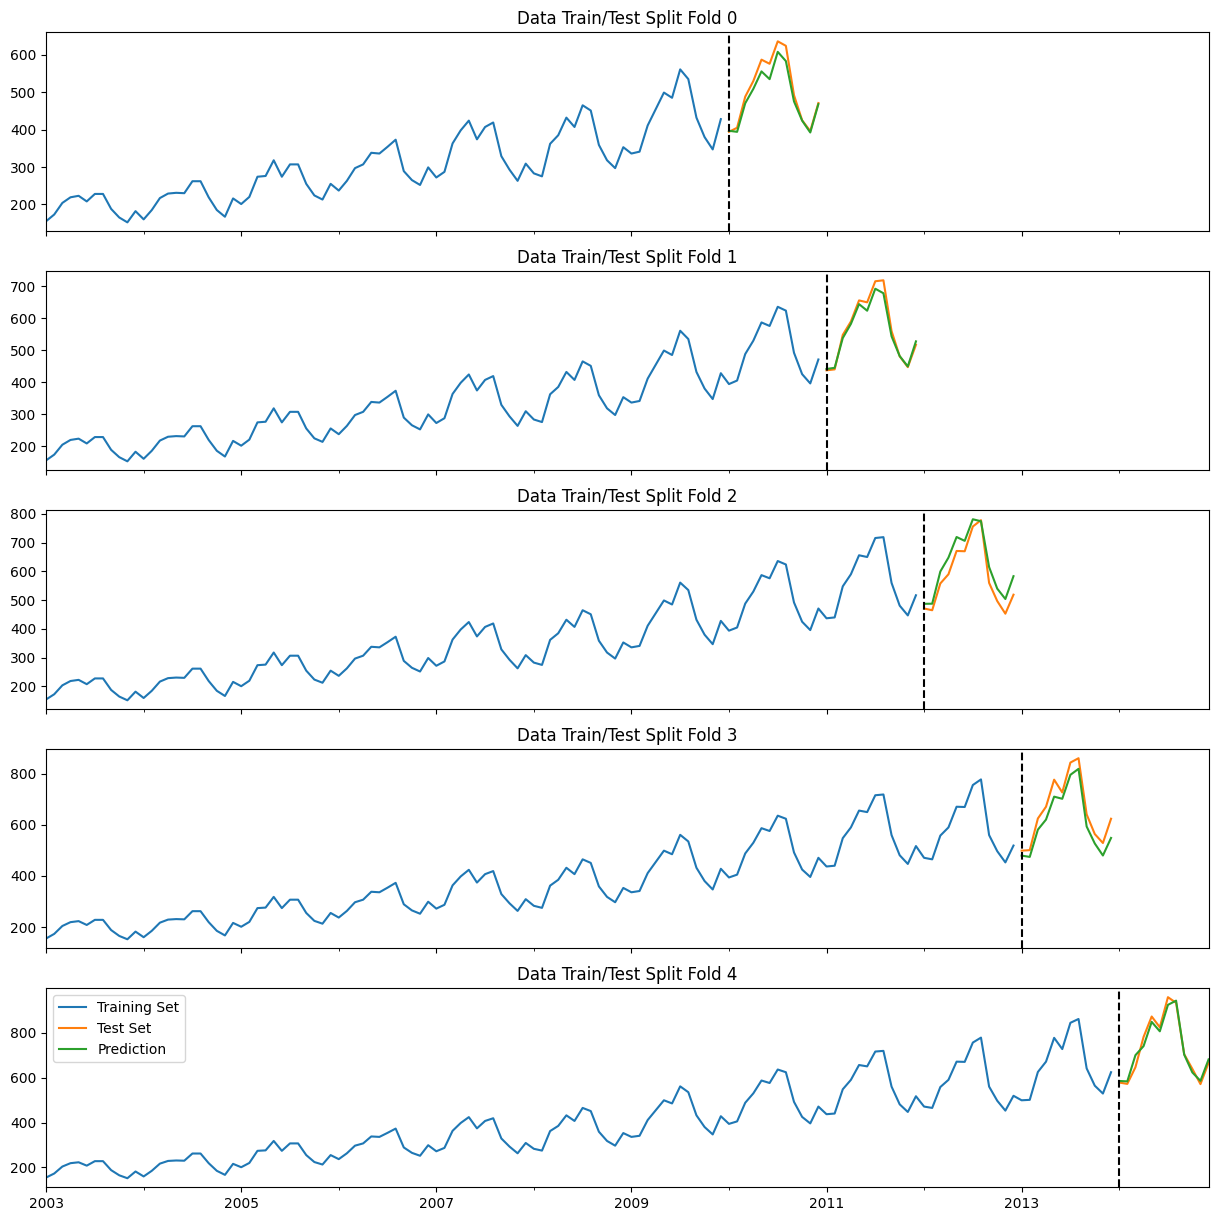

In [ ]:
#splitting the data for 5-fold cross validation
folds = 5
tss = TimeSeriesSplit(n_splits=folds, test_size=12,gap=0)
df = df.sort_index()
fig, axs = plt.subplots(folds, 1, figsize=(15, 15), sharex=True)
fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['Number_Trucks_Sold'].plot(ax=axs[fold],
                          label='Training Set',
                          title=f'Data Train/Test Split Fold {fold}')
    test['Number_Trucks_Sold'].plot(ax=axs[fold],
                         label='Test Set')
    predsdf[fold].plot(ax=axs[fold],
                         label='Prediction')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


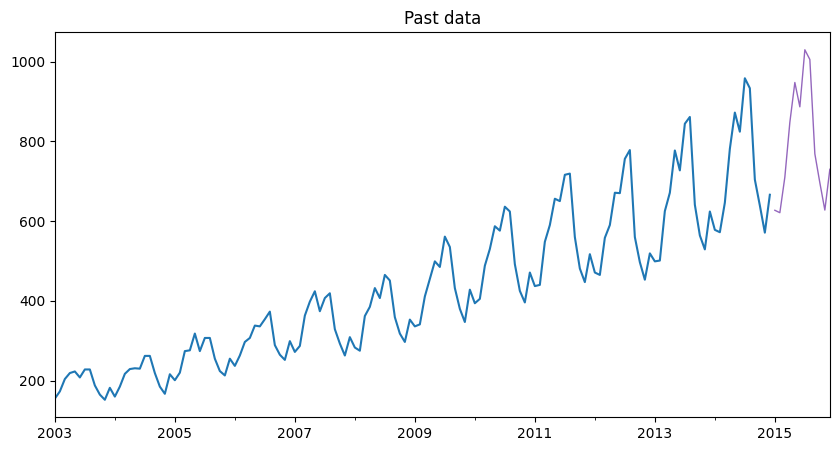

In [ ]:
#create a prediction for the future
model = SARIMAX(df['Number_Trucks_Sold'], order=(2,1,2), seasonal_order=(2,1,2,12))
model = model.fit(disp=False)
df.index.max()
# Create future dataframe with monthly frequency
future = pd.date_range(start=df.index.max() + pd.DateOffset(months=1),
                       end=df.index.max() + pd.DateOffset(years=1), freq='MS')
future_df = pd.DataFrame(index=future)
future_df['isFuture'] = True
df['isFuture'] = False
df_and_future = pd.concat([df, future_df])

# Re-apply create_features and add_lags on the combined dataframe
future_w_features = df_and_future.query('isFuture').copy()
future_w_features['pred'] = model.forecast(steps=12)
future_w_features['pred'].plot(figsize=(10, 5),
                               color=color_pal()[4],
                               ms=1,
                               lw=1,
                               title='Future Prediction')
df['Number_Trucks_Sold'].plot(title='Past data')


plt.show()


As seen in the plots above, the Seasonal ARIMA model performs much better than the XGBoost model, with a CV score of 30.9 compared to the 45.6 of XGBoost. It captures the shape and peaks of the data much better, while XGBoost tended to predict low on the peaks

- Discuss the importance of the data and why time series forecasting is important.

The Kaggle source says this is a dummy dataset, so this particular dataset does not have much forecasting importance except as a learning experience. However, for someone with a real company selling trucks, this sort of data could be very important for decision making. They could gain valuable information about when to stock up on vehicles (in the summer for this dataset) and whether to increase their supply each year (they should increase it regularly for this dataset)

More broadly, time series forecasting can help predict various things with seasonality or a long term trend, helping supply meet the demand that changes throughout the day/month/year. It can ensure that the power grid provides the right amount of power at a given time of day or year, and can also help predict things like the weather at a given time of year or population growth over time.